In [3]:
import pandas as pd
import seaborn as sns

In [4]:
df = pd.read_csv("Copy of Excercise Dummy Numbers - Sheet1.csv")

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 210 entries, 0 to 209
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   Country_id  210 non-null    object
 1   client_id   210 non-null    int64 
 2   date_month  210 non-null    object
 3   product     210 non-null    object
 4   GMV         210 non-null    int64 
dtypes: int64(2), object(3)
memory usage: 8.3+ KB


In [6]:
df.head()

,Country_id,client_id,date_month,product,GMV
0,USA,1376,2025-01-01,AI,246
1,MX,1970,2025-01-01,Enterprise,119
2,MX,1733,2025-01-01,New,265
3,MX,1734,2025-01-01,New,401
4,MX,1735,2025-01-01,New,386


In [7]:
df["client_id"].nunique()

195

In [8]:
df["client_id"].value_counts()

client_id
1741    2
1758    2
1269    2
1173    2
1282    2
       ..
1358    1
1675    1
1583    1
1031    1
1696    1
Name: count, Length: 195, dtype: int64

In [9]:
df.query("client_id == 1741")

,Country_id,client_id,date_month,product,GMV
10,MX,1741,2025-01-01,Enterprise,100
139,BZ,1741,2025-02-01,New,287


In [10]:
df.describe()

,client_id,GMV
count,210.000000,210.000000
mean,1536.547619,248.547619
std,269.550130,156.236204
min,1005.000000,53.000000
25%,1320.000000,150.500000
50%,1548.000000,220.000000
75%,1747.750000,279.000000
max,1991.000000,891.000000


In [13]:
df.groupby("product")["GMV"].mean().reset_index()

,product,GMV
0,AI,453.666667
1,Enterprise,177.165049
2,New,206.288136


In [14]:
df["date_month"] = pd.to_datetime(df["date_month"])

In [15]:
across_time = df.groupby("date_month")["GMV"].sum()
across_time.head()

date_month
2025-01-01    18295
2025-02-01    14335
2025-03-01    19565
Name: GMV, dtype: int64

In [16]:
time_country = df.groupby(["date_month","Country_id"])["GMV"].sum().reset_index()

In [18]:
time_country

,date_month,Country_id,GMV
0,2025-01-01,BZ,4605
1,2025-01-01,MX,6602
2,2025-01-01,USA,7088
3,2025-02-01,BZ,3085
4,2025-02-01,MX,4833
5,2025-02-01,USA,6417
6,2025-03-01,BZ,10585
7,2025-03-01,MX,2848
8,2025-03-01,USA,6132


In [20]:
time_product = df.groupby(["date_month","product"])["GMV"].sum().reset_index()
time_product

,date_month,product,GMV
0,2025-01-01,AI,7005
1,2025-01-01,Enterprise,6537
2,2025-01-01,New,4753
3,2025-02-01,AI,4123
4,2025-02-01,Enterprise,6203
5,2025-02-01,New,4009
6,2025-03-01,AI,10648
7,2025-03-01,Enterprise,5508
8,2025-03-01,New,3409


<Axes: xlabel='product', ylabel='GMV'>

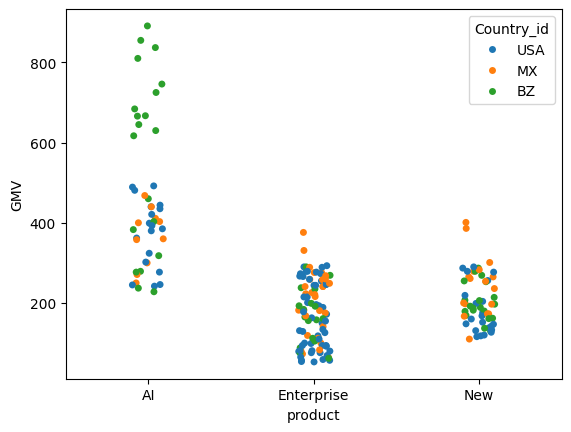

In [25]:
sns.stripplot(data = df, x="product",y = "GMV",hue = "Country_id")

<Axes: xlabel='date_month', ylabel='GMV'>

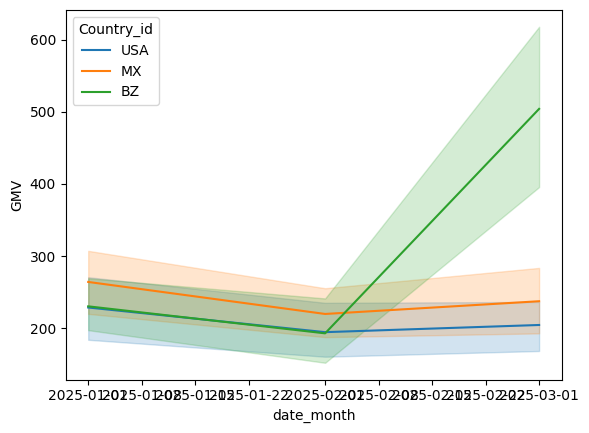

In [27]:
sns.lineplot(data = df,x = "date_month", y = "GMV",hue = "Country_id")

-The AI product is the one with the most GMV
-It is the product that dropped the most MoM (-50%)
-Brazil is our best contributor on average (320 units of GMV)
-It seems to be an outlier in the Brazil Market in the month of March, maybe the release of a new product, or some kind of promotion
-Maybe in February we have issues with the AI category that explain that 50% drop


<Axes: xlabel='Country_id', ylabel='GMV'>

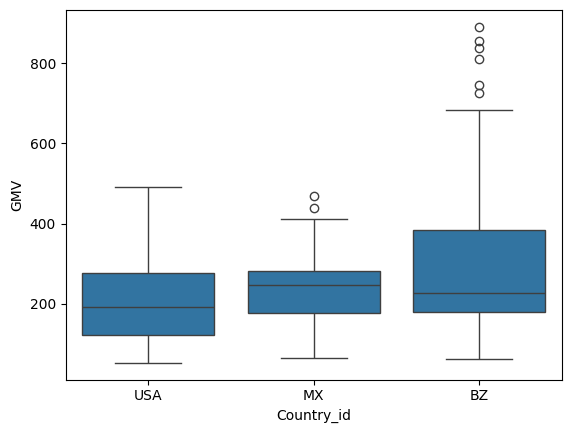

In [32]:
sns.boxplot(data = df, x="Country_id", y = "GMV")

After reviewing the distribution of the GMV by country, we can see that indeed there are outliers in the Brazil market, as I said maybe because of the promotion or the release of a new AI product